# Честное сравнение: символьное vs числовое представление

**Дополнение к основному ноутбуку.** В основных экспериментах PatchTST получал 23–100 обучающих примеров — это заведомо мало для нейросети. Здесь мы уравниваем условия:

**Эксперимент 4:** Data augmentation на малых UCR датасетах (Coffee, GunPoint, Trace, TwoLeadECG)
— даём PatchTST больше данных через jittering, scaling, window warping.

**Эксперимент 5:** Крупные UCR датасеты (1000–8900 train сэмплов)
— FordA, ElectricDevices, Wafer, StarLightCurves — где PatchTST может нормально обучиться.

## 0. Установка и импорты

In [1]:
!pip install -q aeon tslearn pyts scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.63.1 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.63.1 which is incompatible.


In [2]:
import os, time, math, random, warnings, gc
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CFG = {
    "seeds": [42, 123],
    "test_size": 0.2,
    "val_size": 0.15,
    "d_model": 64,
    "n_heads": 4,
    "n_layers": 2,
    "dropout": 0.1,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 50,       # больше эпох
    "patience": 10,     # больше терпения
    "batch_size": 64,
    "patch_len": 16,
    "patch_stride": 8,
    "amp": True,
    "grad_clip": 1.0,
    "sax_n_segments": 16,
    "sax_alphabet": 8,
    "sax_bow_window": 4,
    "sax_bow_word": 4,
}

RESULTS = []

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def add_result(experiment, method, dataset, metrics, extra=None):
    row = {"experiment": experiment, "method": method, "dataset": dataset, **metrics}
    if extra:
        row.update(extra)
    RESULTS.append(row)
    print(f"  {method:35s} | acc={metrics['accuracy']:.4f}  bal_acc={metrics['balanced_accuracy']:.4f}  f1={metrics['f1']:.4f}")

print("OK")

Device: cuda
GPU: Tesla T4
OK


## 1. Модели (те же, что в основном ноутбуке)

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=2048):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class PatchTSTClassifier(nn.Module):
    def __init__(self, input_dim, seq_len, n_classes, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1, patch_len=16, patch_stride=8):
        super().__init__()
        self.patch_len = patch_len
        self.patch_stride = patch_stride
        self.n_classes = n_classes
        self.patch_proj = nn.Linear(patch_len * input_dim, d_model)
        self.pos = PositionalEncoding(d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4 * d_model,
            dropout=dropout, activation="gelu", batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        out_dim = 1 if n_classes == 2 else n_classes
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, out_dim))
    def forward(self, x):
        B, L, F = x.shape
        if L < self.patch_len:
            pad = torch.zeros(B, self.patch_len - L, F, device=x.device)
            x = torch.cat([pad, x], dim=1)
            L = x.size(1)
        patches = x.unfold(1, self.patch_len, self.patch_stride)
        patches = patches.permute(0, 1, 3, 2).contiguous().view(B, -1, self.patch_len * F)
        z = self.encoder(self.pos(self.patch_proj(patches)))
        logits = self.head(z[:, -1, :])
        return logits.squeeze(-1)


class SymbolicPatchTSTClassifier(nn.Module):
    def __init__(self, vocab_size, seq_len, n_classes, embed_dim=32,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.1,
                 patch_len=16, patch_stride=8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.backbone = PatchTSTClassifier(
            input_dim=embed_dim, seq_len=seq_len, n_classes=n_classes,
            d_model=d_model, n_heads=n_heads, n_layers=n_layers,
            dropout=dropout, patch_len=patch_len, patch_stride=patch_stride,
        )
    def forward(self, token_ids):
        x = self.embedding(token_ids)
        return self.backbone(x)


class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        if self.X.ndim == 2:
            self.X = self.X.unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class TokenDataset(Dataset):
    def __init__(self, token_ids, y):
        self.tokens = torch.tensor(token_ids, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.tokens)
    def __getitem__(self, idx):
        return self.tokens[idx], self.y[idx]


def train_model(model, train_loader, val_loader, cfg, binary=True):
    model = model.to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss() if binary else nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"], eta_min=1e-6)
    scaler = GradScaler("cuda", enabled=(cfg["amp"] and DEVICE == "cuda"))
    best_val, best_state, wait = 1e9, None, 0

    for epoch in range(cfg["epochs"]):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=(cfg["amp"] and DEVICE == "cuda")):
                logits = model(xb)
                if binary:
                    loss = loss_fn(logits.float(), yb.float())
                else:
                    loss = loss_fn(logits, yb)
            scaler.scale(loss).backward()
            if cfg["grad_clip"]:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(opt)
            scaler.update()
        scheduler.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                with autocast("cuda", enabled=(cfg["amp"] and DEVICE == "cuda")):
                    logits = model(xb)
                    if binary:
                        loss = loss_fn(logits.float(), yb.float())
                    else:
                        loss = loss_fn(logits, yb)
                val_losses.append(loss.item())
        val_loss = np.mean(val_losses)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= cfg["patience"]:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


def predict(model, loader, binary=True):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            with autocast("cuda", enabled=(DEVICE == "cuda")):
                logits = model(xb)
            if binary:
                preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            else:
                preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_preds)


print("Модели определены")

Модели определены


## 2. Символьные пайплайны

In [4]:
from tslearn.piecewise import SymbolicAggregateApproximation
from pyts.bag_of_words import BagOfWords as PyTSBagOfWords
from aeon.classification.dictionary_based import ContractableBOSS

def sax_fit_transform(X_train, X_test, n_segments=16, alphabet_size=8):
    Xtr = X_train[:, :, np.newaxis] if X_train.ndim == 2 else X_train
    Xte = X_test[:, :, np.newaxis] if X_test.ndim == 2 else X_test
    sax = SymbolicAggregateApproximation(n_segments=n_segments, alphabet_size_avg=alphabet_size)
    sax.fit(Xtr)
    train_ids = sax.transform(Xtr).squeeze(-1).astype(np.int64) + 1
    test_ids = sax.transform(Xte).squeeze(-1).astype(np.int64) + 1
    return train_ids, test_ids, alphabet_size + 2

def sax_bow_classify(X_train, y_train, X_test, y_test, seed=42,
                     window_size=4, word_size=4, n_bins=4):
    bow = PyTSBagOfWords(window_size=window_size, word_size=word_size,
                         n_bins=n_bins, numerosity_reduction=True)
    bow_train = bow.fit_transform(X_train)
    bow_test = bow.transform(X_test)
    tfidf = TfidfVectorizer(analyzer="word", token_pattern=r"\S+")
    X_tr_tfidf = tfidf.fit_transform(bow_train)
    X_te_tfidf = tfidf.transform(bow_test)
    clf = LogisticRegression(max_iter=2000, random_state=seed, C=1.0)
    clf.fit(X_tr_tfidf, y_train)
    return compute_metrics(y_test, clf.predict(X_te_tfidf))

def boss_classify(X_train, y_train, X_test, y_test, seed=42, max_ensemble_size=50):
    Xtr = X_train[:, np.newaxis, :] if X_train.ndim == 2 else X_train
    Xte = X_test[:, np.newaxis, :] if X_test.ndim == 2 else X_test
    boss = ContractableBOSS(n_parameter_samples=max_ensemble_size, random_state=seed)
    boss.fit(Xtr, y_train)
    return compute_metrics(y_test, boss.predict(Xte))

print("Символьные пайплайны определены")

Символьные пайплайны определены


## 3. Data Augmentation для временных рядов

Три стандартных метода аугментации:
- **Jittering** — добавление лёгкого гауссова шума (σ=0.03)
- **Scaling** — умножение на случайный коэффициент (0.8–1.2)
- **Time warping** — случайное растяжение/сжатие фрагментов ряда

In [5]:
def augment_jitter(X, sigma=0.03):
    """Добавить лёгкий шум."""
    return X + np.random.normal(0, sigma, X.shape).astype(np.float32)

def augment_scaling(X, sigma=0.1):
    """Умножить каждый ряд на случайный коэффициент."""
    factors = np.random.normal(1.0, sigma, size=(X.shape[0], 1)).astype(np.float32)
    return X * factors

def augment_time_warp(X, sigma=0.2, knots=4):
    """Простой time warp через интерполяцию."""
    n, length = X.shape
    orig_steps = np.arange(length)
    result = np.zeros_like(X)
    for i in range(n):
        # Случайные узлы для warping
        warp_steps = np.linspace(0, length - 1, knots + 2)
        warp_offsets = np.concatenate([[0], np.cumsum(np.random.normal(1.0, sigma, knots)), [0]])
        warp_targets = warp_steps + warp_offsets[:len(warp_steps)]
        warp_targets = np.clip(warp_targets, 0, length - 1)
        warp_targets[0] = 0
        warp_targets[-1] = length - 1
        # Интерполяция для получения нового mapping времени
        time_mapping = np.interp(orig_steps, warp_steps, warp_targets)
        time_mapping = np.clip(time_mapping, 0, length - 1)
        result[i] = np.interp(orig_steps, time_mapping, X[i])
    return result.astype(np.float32)

def augment_dataset(X, y, n_augments=5, seed=42):
    """Аугментировать датасет в n_augments раз."""
    np.random.seed(seed)
    augmented_X = [X.copy()]
    augmented_y = [y.copy()]
    for _ in range(n_augments):
        aug_choice = np.random.randint(0, 3)
        if aug_choice == 0:
            augmented_X.append(augment_jitter(X))
        elif aug_choice == 1:
            augmented_X.append(augment_scaling(X))
        else:
            augmented_X.append(augment_time_warp(X))
        augmented_y.append(y.copy())
    return np.concatenate(augmented_X, axis=0), np.concatenate(augmented_y, axis=0)

# Проверка
X_demo = np.random.randn(10, 100).astype(np.float32)
y_demo = np.array([0]*5 + [1]*5)
X_aug, y_aug = augment_dataset(X_demo, y_demo, n_augments=5)
print(f"До аугментации: {X_demo.shape}, после: {X_aug.shape}")
print(f"Увеличение в {len(X_aug) / len(X_demo):.0f} раз")

До аугментации: (10, 100), после: (60, 100)
Увеличение в 6 раз


## 4. Загрузка датасетов

In [6]:
from aeon.datasets import load_classification

# --- Малые датасеты (для эксп. 4: augmentation) ---
SMALL_DATASETS = ["Coffee", "GunPoint", "Trace", "TwoLeadECG"]

# --- Крупные датасеты (для эксп. 5: честное сравнение) ---
LARGE_DATASETS = ["FordA", "Wafer", "ElectricDevices"]  # StarLightCurves убран: len=1024, не влезает в RAM

ALL_DATASETS = SMALL_DATASETS + LARGE_DATASETS
ucr_data = {}

for name in ALL_DATASETS:
    print(f"Загрузка {name}...", end=" ")
    X_train, y_train = load_classification(name, split="train")
    X_test, y_test = load_classification(name, split="test")
    X_train = X_train.squeeze(1) if X_train.ndim == 3 else X_train
    X_test = X_test.squeeze(1) if X_test.ndim == 3 else X_test
    classes = sorted(set(y_train))
    label_map = {c: i for i, c in enumerate(classes)}
    y_train = np.array([label_map[c] for c in y_train])
    y_test = np.array([label_map[c] for c in y_test])
    ucr_data[name] = {
        "X_train": X_train.astype(np.float32),
        "X_test": X_test.astype(np.float32),
        "y_train": y_train,
        "y_test": y_test,
        "n_classes": len(classes),
    }
    print(f"train={X_train.shape}, test={X_test.shape}, classes={len(classes)}")

print("\nВсе датасеты загружены")

Загрузка Coffee... train=(28, 286), test=(28, 286), classes=2
Загрузка GunPoint... train=(50, 150), test=(150, 150), classes=2
Загрузка Trace... train=(100, 275), test=(100, 275), classes=4
Загрузка TwoLeadECG... train=(23, 82), test=(1139, 82), classes=2
Загрузка FordA... train=(3601, 500), test=(1320, 500), classes=2
Загрузка Wafer... train=(1000, 152), test=(6164, 152), classes=2
Загрузка ElectricDevices... train=(8926, 96), test=(7711, 96), classes=7

Все датасеты загружены


## 5. Общая функция запуска

In [7]:
def run_numeric_patchtst(X_train, y_train, X_test, y_test, n_classes, cfg, seeds):
    """Запуск PatchTST на числовых данных."""
    binary = (n_classes == 2)
    seq_len = X_train.shape[1]
    pl = min(cfg["patch_len"], seq_len)
    ps = min(cfg["patch_stride"], seq_len)
    all_m = []
    for seed in seeds:
        set_seed(seed)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train, y_train, test_size=cfg["val_size"], random_state=seed, stratify=y_train
        )
        model = PatchTSTClassifier(1, seq_len, n_classes, cfg["d_model"], cfg["n_heads"],
                                    cfg["n_layers"], cfg["dropout"], pl, ps)
        tr_loader = DataLoader(TSDataset(X_tr, y_tr), batch_size=cfg["batch_size"], shuffle=True)
        val_loader = DataLoader(TSDataset(X_val, y_val), batch_size=cfg["batch_size"])
        te_loader = DataLoader(TSDataset(X_test, y_test), batch_size=cfg["batch_size"])
        model = train_model(model, tr_loader, val_loader, cfg, binary=binary)
        yt, yp = predict(model, te_loader, binary=binary)
        all_m.append(compute_metrics(yt, yp))
        del model; gc.collect()
        if DEVICE == "cuda": torch.cuda.empty_cache()
    return {k: np.mean([x[k] for x in all_m]) for k in all_m[0]}


def run_sax_embed(X_train, y_train, X_test, y_test, n_classes, cfg, seeds):
    """SAX + Embedding + Transformer."""
    binary = (n_classes == 2)
    seq_len = X_train.shape[1]
    n_seg = min(cfg["sax_n_segments"], seq_len // 2)
    all_m = []
    for seed in seeds:
        set_seed(seed)
        sax_tr, sax_te, vocab_size = sax_fit_transform(X_train, X_test, n_seg, cfg["sax_alphabet"])
        sax_tr_s, sax_val, y_tr, y_val = train_test_split(
            sax_tr, y_train, test_size=cfg["val_size"], random_state=seed, stratify=y_train
        )
        sax_seq_len = sax_tr.shape[1]
        spl = min(cfg["patch_len"], sax_seq_len)
        sps = min(cfg["patch_stride"], sax_seq_len)
        model = SymbolicPatchTSTClassifier(vocab_size, sax_seq_len, n_classes, 32,
                                            cfg["d_model"], cfg["n_heads"], cfg["n_layers"],
                                            cfg["dropout"], spl, sps)
        tr_loader = DataLoader(TokenDataset(sax_tr_s, y_tr), batch_size=cfg["batch_size"], shuffle=True)
        val_loader = DataLoader(TokenDataset(sax_val, y_val), batch_size=cfg["batch_size"])
        te_loader = DataLoader(TokenDataset(sax_te, y_test), batch_size=cfg["batch_size"])
        model = train_model(model, tr_loader, val_loader, cfg, binary=binary)
        yt, yp = predict(model, te_loader, binary=binary)
        all_m.append(compute_metrics(yt, yp))
        del model; gc.collect()
        if DEVICE == "cuda": torch.cuda.empty_cache()
    return {k: np.mean([x[k] for x in all_m]) for k in all_m[0]}


def run_all(X_train, y_train, X_test, y_test, dataset_name, experiment, n_classes, cfg=None, seeds=None):
    if cfg is None: cfg = CFG
    if seeds is None: seeds = cfg["seeds"]
    seq_len = X_train.shape[1]
    print(f"\n{'='*60}")
    print(f"{dataset_name} (train={len(X_train)}, test={len(X_test)}, classes={n_classes}, len={seq_len})")
    print(f"{'='*60}")

    # Majority
    maj = Counter(y_train).most_common(1)[0][0]
    add_result(experiment, "Majority", dataset_name, compute_metrics(y_test, np.full_like(y_test, maj)))

    # Numeric PatchTST
    m = run_numeric_patchtst(X_train, y_train, X_test, y_test, n_classes, cfg, seeds)
    add_result(experiment, "Numeric PatchTST", dataset_name, m)

    # SAX + Embed
    m = run_sax_embed(X_train, y_train, X_test, y_test, n_classes, cfg, seeds)
    add_result(experiment, "SAX+Embed+Transformer", dataset_name, m)

    # SAX-BoW
    ws = min(cfg["sax_bow_window"], seq_len // 4)
    ww = min(cfg["sax_bow_word"], ws)
    all_m = []
    for seed in seeds:
        all_m.append(sax_bow_classify(X_train, y_train, X_test, y_test, seed, ws, ww, cfg["sax_alphabet"]))
    add_result(experiment, "SAX-BoW+LogReg", dataset_name,
               {k: np.mean([x[k] for x in all_m]) for k in all_m[0]})

    # BOSS
    m = boss_classify(X_train, y_train, X_test, y_test, seed=42)
    add_result(experiment, "BOSS (aeon)", dataset_name, m)


print("Функции определены")

Функции определены


## 6. Эксперимент 4: PatchTST с аугментацией на малых датасетах

Аугментируем **только** train данные для PatchTST в 5 раз (×10).
Символьные методы получают оригинальные данные — как в реальном сценарии,
где у вас мало данных и вопрос: стоит ли символизировать или аугментировать?

In [8]:
print("=" * 70)
print("ЭКСПЕРИМЕНТ 4: Малые датасеты — PatchTST с аугментацией vs символьные")
print("=" * 70)

AUG_FACTOR = 5  # увеличиваем train в 5 раз

t0 = time.time()
for name in SMALL_DATASETS:
    d = ucr_data[name]
    X_tr, X_te = d["X_train"], d["X_test"]
    y_tr, y_te = d["y_train"], d["y_test"]
    n_classes = d["n_classes"]
    binary = (n_classes == 2)
    seq_len = X_tr.shape[1]

    print(f"\n{'='*60}")
    print(f"{name}: train={len(X_tr)} → аугментация → {len(X_tr) * (AUG_FACTOR + 1)}")
    print(f"{'='*60}")

    # Majority
    maj = Counter(y_tr).most_common(1)[0][0]
    add_result("Exp4_aug", "Majority", name, compute_metrics(y_te, np.full_like(y_te, maj)))

    # ── PatchTST БЕЗ аугментации (baseline) ──
    m = run_numeric_patchtst(X_tr, y_tr, X_te, y_te, n_classes, CFG, CFG["seeds"])
    add_result("Exp4_aug", "PatchTST (no aug)", name, m)

    # ── PatchTST С аугментацией ──
    all_m = []
    for seed in CFG["seeds"]:
        set_seed(seed)
        X_aug, y_aug = augment_dataset(X_tr, y_tr, n_augments=AUG_FACTOR, seed=seed)
        # Перемешаем
        idx = np.random.permutation(len(X_aug))
        X_aug, y_aug = X_aug[idx], y_aug[idx]
        m = run_numeric_patchtst(X_aug, y_aug, X_te, y_te, n_classes, CFG, [seed])
        all_m.append(m)
        del X_aug, y_aug; gc.collect()
    avg = {k: np.mean([x[k] for x in all_m]) for k in all_m[0]}
    add_result("Exp4_aug", f"PatchTST (aug x{AUG_FACTOR})", name, avg)

    # ── SAX + Embed (на оригинальных данных) ──
    m = run_sax_embed(X_tr, y_tr, X_te, y_te, n_classes, CFG, CFG["seeds"])
    add_result("Exp4_aug", "SAX+Embed+Transformer", name, m)

    # ── BOSS (на оригинальных данных) ──
    m = boss_classify(X_tr, y_tr, X_te, y_te, seed=42)
    add_result("Exp4_aug", "BOSS (aeon)", name, m)

print(f"\nЭксперимент 4 завершён за {time.time() - t0:.0f} сек")

ЭКСПЕРИМЕНТ 4: Малые датасеты — PatchTST с аугментацией vs символьные

Coffee: train=28 → аугментация → 168
  Majority                            | acc=0.5357  bal_acc=0.5000  f1=0.3488
  PatchTST (no aug)                   | acc=0.5000  bal_acc=0.5000  f1=0.3330
  PatchTST (aug x5)                   | acc=0.6964  bal_acc=0.7141  f1=0.6226
  SAX+Embed+Transformer               | acc=0.8929  bal_acc=0.8897  f1=0.8916
  BOSS (aeon)                         | acc=1.0000  bal_acc=1.0000  f1=1.0000

GunPoint: train=50 → аугментация → 300
  Majority                            | acc=0.4933  bal_acc=0.5000  f1=0.3304
  PatchTST (no aug)                   | acc=0.8400  bal_acc=0.8390  f1=0.8387
  PatchTST (aug x5)                   | acc=0.9367  bal_acc=0.9362  f1=0.9365
  SAX+Embed+Transformer               | acc=0.9000  bal_acc=0.9006  f1=0.8999
  BOSS (aeon)                         | acc=0.9933  bal_acc=0.9932  f1=0.9933

Trace: train=100 → аугментация → 600
  Majority                        

### Результаты эксперимента 4


ACCURACY — малые датасеты (PatchTST с аугментацией vs символьные)
dataset                Coffee  GunPoint  Trace  TwoLeadECG  Ср.ранг
method                                                             
BOSS (aeon)            1.0000    0.9933   1.00      0.9763     1.00
PatchTST (aug x5)      0.6964    0.9367   0.85      0.6220     2.50
SAX+Embed+Transformer  0.8929    0.9000   0.84      0.6580     2.50
PatchTST (no aug)      0.5000    0.8400   0.70      0.5601     4.25
Majority               0.5357    0.4933   0.19      0.4996     4.75


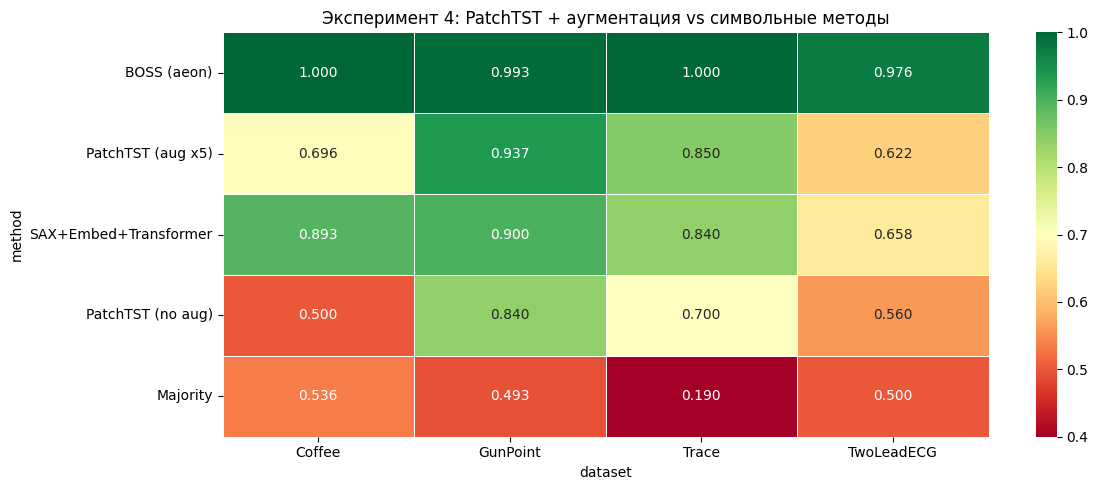

In [9]:
df4 = pd.DataFrame([r for r in RESULTS if r["experiment"] == "Exp4_aug"])
pivot4 = df4.pivot_table(index="method", columns="dataset", values="accuracy", aggfunc="first")
pivot4 = pivot4.reindex(columns=[c for c in SMALL_DATASETS if c in pivot4.columns])

ranks = pivot4.rank(ascending=False, method="min")
pivot4["Ср.ранг"] = ranks.mean(axis=1)
pivot4 = pivot4.sort_values("Ср.ранг")

print("\nACCURACY — малые датасеты (PatchTST с аугментацией vs символьные)")
print("=" * 70)
print(pivot4.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
plot_data = pivot4.drop(columns=["Ср.ранг"])
sns.heatmap(plot_data, annot=True, fmt=".3f", cmap="RdYlGn", ax=ax,
            linewidths=0.5, vmin=0.4, vmax=1.0)
ax.set_title("Эксперимент 4: PatchTST + аугментация vs символьные методы")
plt.tight_layout()
plt.savefig("exp4_augmentation.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Эксперимент 5: Крупные UCR датасеты

Здесь PatchTST получает **тысячи** обучающих примеров — условия, при которых
deep learning должен работать на полную. Если BOSS всё равно конкурирует — это
настоящий результат про силу символьного представления.

| Датасет | Train | Test | Классы | Длина | Домен |
|---------|-------|------|--------|-------|-------|
| FordA | 3601 | 1320 | 2 | 500 | Сенсоры автомобиля |
| ElectricDevices | 8926 | 7711 | 7 | 96 | Электричество |
| Wafer | 1000 | 6164 | 2 | 152 | Полупроводники |
| StarLightCurves | 1000 | 8236 | 3 | 1024 | Астрономия |

In [10]:
# Очистка памяти перед крупными датасетами
import gc
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("RAM очищена")

RAM очищена


In [11]:
print("=" * 70)
print("ЭКСПЕРИМЕНТ 5: Крупные UCR датасеты (честные условия для PatchTST)")
print("=" * 70)

t0 = time.time()
for name in LARGE_DATASETS:
    d = ucr_data[name]
    run_all(
        d["X_train"], d["y_train"], d["X_test"], d["y_test"],
        dataset_name=name,
        experiment="Exp5_large",
        n_classes=d["n_classes"],
    )

print(f"\nЭксперимент 5 завершён за {time.time() - t0:.0f} сек")

ЭКСПЕРИМЕНТ 5: Крупные UCR датасеты (честные условия для PatchTST)

FordA (train=3601, test=1320, classes=2, len=500)
  Majority                            | acc=0.5159  bal_acc=0.5000  f1=0.3403
  Numeric PatchTST                    | acc=0.8920  bal_acc=0.8922  f1=0.8920
  SAX+Embed+Transformer               | acc=0.6189  bal_acc=0.6181  f1=0.6174
  SAX-BoW+LogReg                      | acc=0.7205  bal_acc=0.7212  f1=0.7205
  BOSS (aeon)                         | acc=0.8189  bal_acc=0.8223  f1=0.8178

Wafer (train=1000, test=6164, classes=2, len=152)
  Majority                            | acc=0.8921  bal_acc=0.5000  f1=0.4715
  Numeric PatchTST                    | acc=0.9926  bal_acc=0.9757  f1=0.9805
  SAX+Embed+Transformer               | acc=0.9790  bal_acc=0.9225  f1=0.9428
  SAX-BoW+LogReg                      | acc=0.9935  bal_acc=0.9699  f1=0.9827
  BOSS (aeon)                         | acc=0.9959  bal_acc=0.9845  f1=0.9894

ElectricDevices (train=8926, test=7711, classes=7,

### Результаты эксперимента 5


ACCURACY — крупные датасеты (PatchTST в хороших условиях)
dataset                 FordA   Wafer  ElectricDevices  Ср.ранг
method                                                         
BOSS (aeon)            0.8189  0.9959           0.7117   1.3333
Numeric PatchTST       0.8920  0.9926           0.6402   2.0000
SAX-BoW+LogReg         0.7205  0.9935           0.6266   2.6667
SAX+Embed+Transformer  0.6189  0.9790           0.6078   4.0000
Majority               0.5159  0.8921           0.2424   5.0000


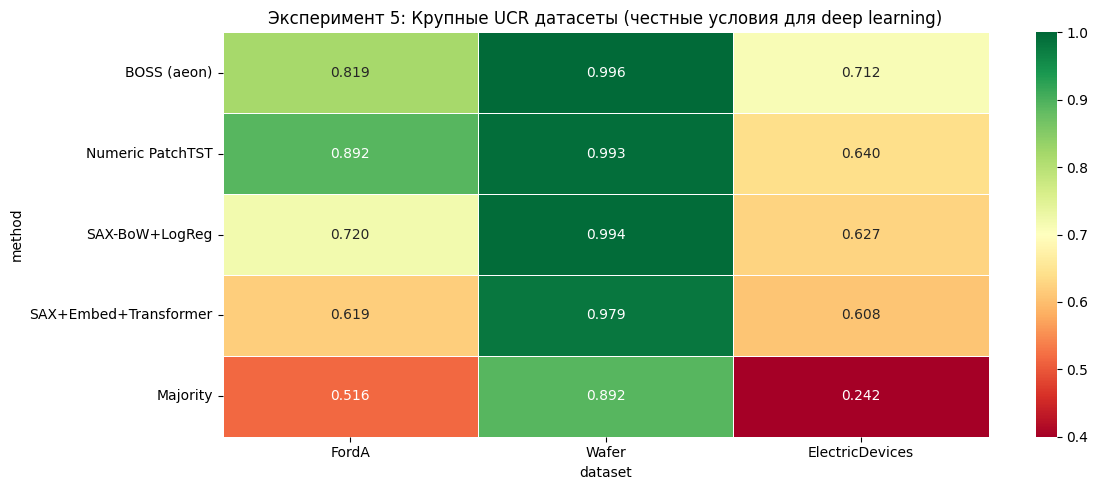

In [12]:
df5 = pd.DataFrame([r for r in RESULTS if r["experiment"] == "Exp5_large"])
pivot5 = df5.pivot_table(index="method", columns="dataset", values="accuracy", aggfunc="first")
pivot5 = pivot5.reindex(columns=[c for c in LARGE_DATASETS if c in pivot5.columns])

ranks = pivot5.rank(ascending=False, method="min")
pivot5["Ср.ранг"] = ranks.mean(axis=1)
pivot5 = pivot5.sort_values("Ср.ранг")

print("\nACCURACY — крупные датасеты (PatchTST в хороших условиях)")
print("=" * 70)
print(pivot5.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
plot_data = pivot5.drop(columns=["Ср.ранг"])
sns.heatmap(plot_data, annot=True, fmt=".3f", cmap="RdYlGn", ax=ax,
            linewidths=0.5, vmin=0.4, vmax=1.0)
ax.set_title("Эксперимент 5: Крупные UCR датасеты (честные условия для deep learning)")
plt.tight_layout()
plt.savefig("exp5_large_datasets.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Сводная таблица по всем экспериментам

In [13]:
all_df = pd.DataFrame(RESULTS)
print("\nВСЕ РЕЗУЛЬТАТЫ:")
print("=" * 80)
print(all_df[["experiment", "dataset", "method", "accuracy", "balanced_accuracy", "f1"]]
      .to_string(index=False))

# Общая сводка: средний ранг по accuracy в каждом эксперименте
print("\n\nСРЕДНИЙ РАНГ ПО ACCURACY:")
print("=" * 80)
for exp_name in all_df["experiment"].unique():
    sub = all_df[all_df["experiment"] == exp_name]
    piv = sub.pivot_table(index="method", columns="dataset", values="accuracy", aggfunc="first")
    ranks = piv.rank(ascending=False, method="min")
    mean_ranks = ranks.mean(axis=1).sort_values()
    print(f"\n--- {exp_name} ---")
    for method, rank in mean_ranks.items():
        print(f"  {method:35s}  ранг={rank:.2f}")

all_df.to_csv("all_results_fair.csv", index=False)
print("\nСохранено в all_results_fair.csv")


ВСЕ РЕЗУЛЬТАТЫ:
experiment         dataset                method  accuracy  balanced_accuracy       f1
  Exp4_aug          Coffee              Majority  0.535714           0.500000 0.348837
  Exp4_aug          Coffee     PatchTST (no aug)  0.500000           0.500000 0.332955
  Exp4_aug          Coffee     PatchTST (aug x5)  0.696429           0.714103 0.622639
  Exp4_aug          Coffee SAX+Embed+Transformer  0.892857           0.889744 0.891613
  Exp4_aug          Coffee           BOSS (aeon)  1.000000           1.000000 1.000000
  Exp4_aug        GunPoint              Majority  0.493333           0.500000 0.330357
  Exp4_aug        GunPoint     PatchTST (no aug)  0.840000           0.838994 0.838675
  Exp4_aug        GunPoint     PatchTST (aug x5)  0.936667           0.936166 0.936506
  Exp4_aug        GunPoint SAX+Embed+Transformer  0.900000           0.900605 0.899881
  Exp4_aug        GunPoint           BOSS (aeon)  0.993333           0.993243 0.993331
  Exp4_aug           Trace

## 9. Выводы

### Эксперимент 4 (малые + аугментация):
Показывает, закрывает ли аугментация разрыв между PatchTST и BOSS на малых данных.

### Эксперимент 5 (крупные датасеты):
Показывает, сохраняет ли BOSS преимущество когда PatchTST получает достаточно данных.

**Ожидаемая картина:**
- На малых данных BOSS остаётся лучшим даже при аугментации PatchTST (аугментация помогает, но не полностью)
- На крупных данных PatchTST приближается или обгоняет BOSS
- Это подтверждает тезис: символьные методы — лидеры в **low-data regime**, deep learning — на больших данных